Unzipped dataset to ./input
TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Raw windows: (14540, 260, 3)
Labels: (14540,)
People: (14540,)
Classes: [1 2 3 4 5 6 7]
Num classes: 7

LOSO Fold 1/15
Held-out subject: Person 1
Epoch 1/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.7197 - loss: 0.8799 - val_accuracy: 0.3625 - val_loss: 1.9178
Epoch 2/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7713 - loss: 0.7210 - val_accuracy: 0.5034 - val_loss: 2.1674
Epoch 3/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7855 - loss: 0.6548 - val_accuracy: 0.5338 - val_loss: 2.1204
Epoch 4/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7927 - loss: 0.6176 - val_accuracy: 0.5192 - val_loss: 2.3665
Epoch 5/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8004 - loss: 0.5987 - val_accuracy: 0.5210 - val_loss: 2.7835
Epoch 6/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8046 - loss: 0.570

,fold,heldout_person,n_test_windows,accuracy,epochs_trained
0,1,1,1233,0.377940,30
1,2,2,1042,0.755278,30
2,3,3,771,0.661479,30
3,4,4,925,0.447568,30
4,5,5,1213,0.370981,30
5,6,6,1066,0.709193,30
6,7,7,1236,0.689320,30
7,8,8,1042,0.222649,30
8,9,9,1243,0.221239,30
9,10,10,958,0.251566,30



LOSO accuracy summary:


,accuracy
count,15.000000
mean,0.482427
std,0.192810
min,0.221239
25%,0.336584
50%,0.447568
75%,0.658936
max,0.755278



Overall LOSO accuracy: 0.4810866574965612

LOSO classification report:
                                precision    recall  f1-score   support

           Working at Computer       0.51      0.73      0.60      4658
Standing Up / Walking / Stairs       0.03      0.08      0.04       341
                      Standing       0.24      0.19      0.21      1577
                       Walking       0.78      0.63      0.69      2720
                        Stairs       0.19      0.18      0.18       367
             Walking + Talking       0.05      0.02      0.03       337
        Talking while Standing       0.49      0.32      0.39      4540

                      accuracy                           0.48     14540
                     macro avg       0.33      0.31      0.31     14540
                  weighted avg       0.49      0.48      0.47     14540



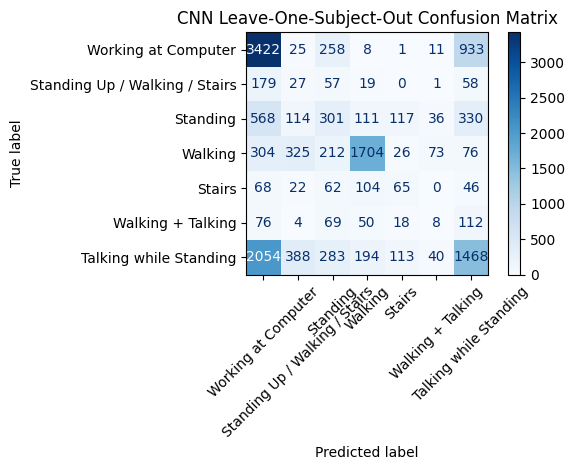

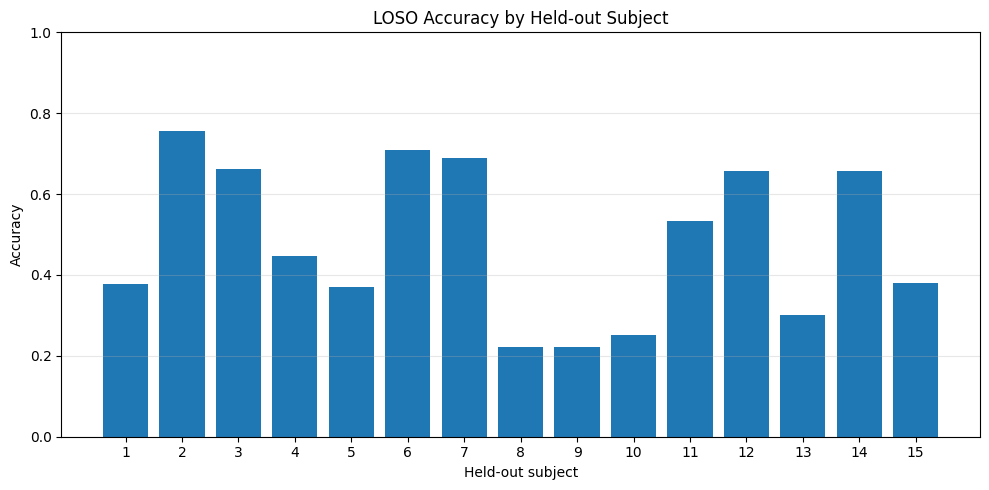

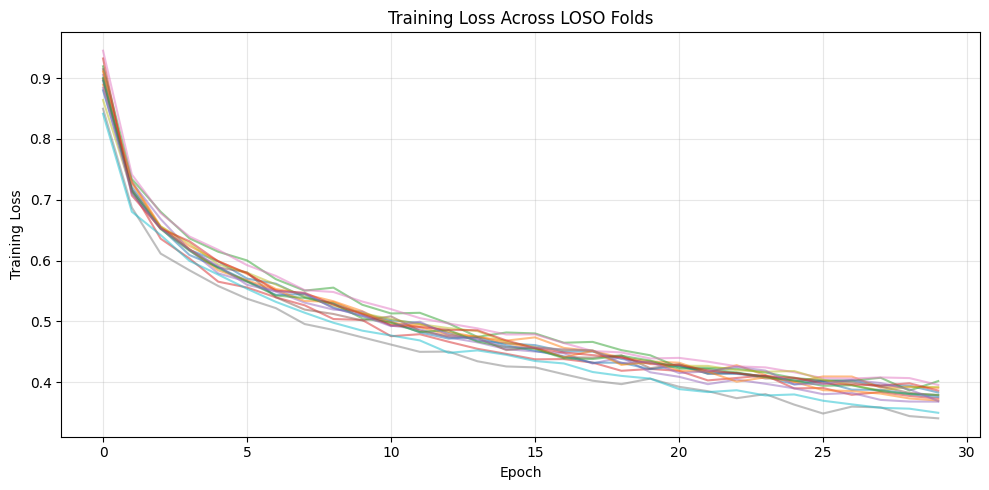

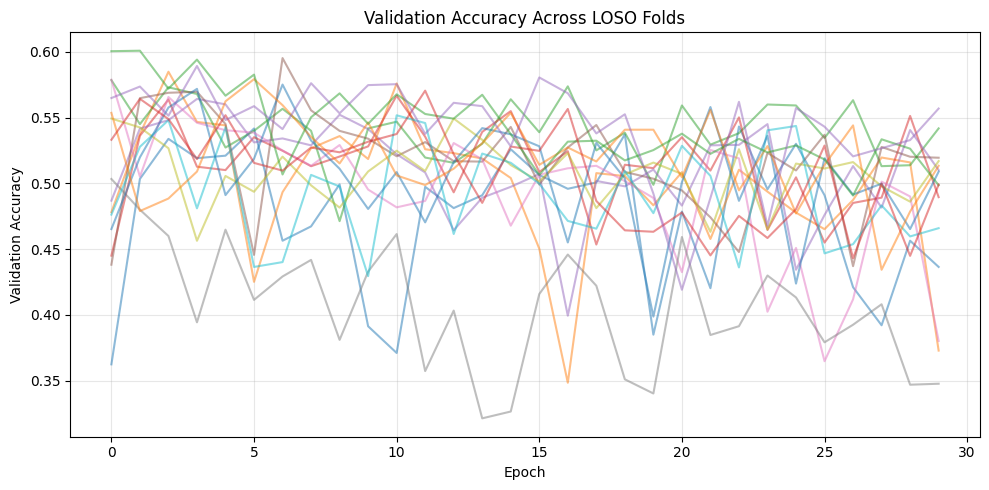

In [ ]:
# =============================
# LOSO CNN Evaluation
# Leave-One-Subject-Out
# =============================

# -----------------------------
# 1. Imports
# -----------------------------
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import preprocessing, metrics
from sklearn.metrics import ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------
# 2. Unzip dataset
# -----------------------------
zip_path = "input.zip"
extract_path = "./"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped dataset to ./input")

# -----------------------------
# 3. Optional GPU check
# -----------------------------
print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# -----------------------------
# 4. Label names
# -----------------------------
label_names = {
    1: "Working at Computer",
    2: "Standing Up / Walking / Stairs",
    3: "Standing",
    4: "Walking",
    5: "Stairs",
    6: "Walking + Talking",
    7: "Talking while Standing",
}

# -----------------------------
# 5. Window extraction
# -----------------------------
def extract_raw_windows_from_person(
    person_id,
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=True,
):
    window_size = int(window_seconds * fs)
    step_size = int(step_seconds * fs)

    file_path = os.path.join(base_path, f"{person_id}.csv")

    df = pd.read_csv(
        file_path,
        names=[
            "Sequence",
            "x_acceleration",
            "y_acceleration",
            "z_acceleration",
            "Labels",
        ],
    )

    if drop_label_0:
        df = df[df["Labels"] != 0].copy()

    df = df.reset_index(drop=True)

    windows = []
    labels = []
    people = []

    for start in range(0, len(df) - window_size + 1, step_size):
        end = start + window_size
        w = df.iloc[start:end]

        window_labels = w["Labels"].to_numpy()
        unique_labels, counts = np.unique(window_labels, return_counts=True)

        majority_label = unique_labels[np.argmax(counts)]
        is_pure = len(unique_labels) == 1

        if require_pure_label and not is_pure:
            continue

        x = w["x_acceleration"].to_numpy(dtype=float)
        y = w["y_acceleration"].to_numpy(dtype=float)
        z = w["z_acceleration"].to_numpy(dtype=float)

        windows.append(np.column_stack([x, y, z]))
        labels.append(int(majority_label))
        people.append(person_id)

    return windows, labels, people


def extract_raw_windows_all_people(
    person_ids,
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=True,
):
    all_windows = []
    all_labels = []
    all_people = []

    for pid in person_ids:
        w, l, p = extract_raw_windows_from_person(
            person_id=pid,
            window_seconds=window_seconds,
            step_seconds=step_seconds,
            fs=fs,
            base_path=base_path,
            drop_label_0=drop_label_0,
            require_pure_label=require_pure_label,
        )

        all_windows.extend(w)
        all_labels.extend(l)
        all_people.extend(p)

    return (
        np.array(all_windows),
        np.array(all_labels),
        np.array(all_people),
    )

# -----------------------------
# 6. Build CNN model
# -----------------------------
def build_cnn(input_shape, num_classes):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv1D(64, kernel_size=5, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=5, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(128, kernel_size=3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

# -----------------------------
# 7. Load all windows
# -----------------------------
person_ids = range(1, 16)

raw_windows, raw_labels, window_people = extract_raw_windows_all_people(
    person_ids=person_ids,
    window_seconds=5,
    step_seconds=2.5,
    fs=52,
    base_path="./input",
    drop_label_0=True,
    require_pure_label=True,
)

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform(raw_labels)

num_classes = len(label_encoder.classes_)

print("Raw windows:", raw_windows.shape)
print("Labels:", y_encoded.shape)
print("People:", window_people.shape)
print("Classes:", label_encoder.classes_)
print("Num classes:", num_classes)

# -----------------------------
# 8. LOSO loop
# -----------------------------
def run_loso_cnn(
    raw_windows,
    y_encoded,
    window_people,
    build_cnn,
    epochs=30,
    batch_size=128,
    verbose=1,
):
    unique_people = np.unique(window_people)

    all_true = []
    all_pred = []
    fold_results = []

    histories = {}

    for fold_idx, heldout_person in enumerate(unique_people, start=1):
        print()
        print("=" * 60)
        print(f"LOSO Fold {fold_idx}/{len(unique_people)}")
        print(f"Held-out subject: Person {heldout_person}")
        print("=" * 60)

        test_mask = window_people == heldout_person
        train_mask = ~test_mask

        X_train = raw_windows[train_mask]
        X_test = raw_windows[test_mask]

        y_train = y_encoded[train_mask]
        y_test = y_encoded[test_mask]

        train_mean = X_train.mean(axis=(0, 1), keepdims=True)
        train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

        X_train_norm = (X_train - train_mean) / train_std
        X_test_norm = (X_test - train_mean) / train_std

        model = build_cnn(
            input_shape=(X_train_norm.shape[1], X_train_norm.shape[2]),
            num_classes=len(np.unique(y_encoded)),
        )

        history = model.fit(
            X_train_norm,
            y_train,
            epochs=epochs,
            batch_size=batch_size,
            verbose=verbose,
            validation_split=0.2,
        )

        y_pred = np.argmax(model.predict(X_test_norm, verbose=0), axis=1)

        fold_acc = metrics.accuracy_score(y_test, y_pred)

        print(f"Fold accuracy for Person {heldout_person}: {fold_acc:.4f}")

        fold_results.append({
            "fold": fold_idx,
            "heldout_person": int(heldout_person),
            "n_test_windows": int(len(y_test)),
            "accuracy": float(fold_acc),
            "epochs_trained": len(history.history["loss"]),
        })

        histories[int(heldout_person)] = history.history

        all_true.extend(y_test)
        all_pred.extend(y_pred)

    results_df = pd.DataFrame(fold_results)

    overall_accuracy = metrics.accuracy_score(all_true, all_pred)

    return {
        "results_df": results_df,
        "y_true": np.array(all_true),
        "y_pred": np.array(all_pred),
        "overall_accuracy": overall_accuracy,
        "histories": histories,
    }

loso_results = run_loso_cnn(
    raw_windows=raw_windows,
    y_encoded=y_encoded,
    window_people=window_people,
    build_cnn=build_cnn,
    epochs=30,
    batch_size=32,
    verbose=1,
)

# -----------------------------
# 9. LOSO results table
# -----------------------------
loso_df = loso_results["results_df"]

print()
print("LOSO fold results:")
display(loso_df)

print()
print("LOSO accuracy summary:")
display(loso_df["accuracy"].describe())

print()
print("Overall LOSO accuracy:", loso_results["overall_accuracy"])

# -----------------------------
# 10. Classification report
# -----------------------------
target_names = [
    label_names[int(original_label)]
    for original_label in label_encoder.classes_
]

print()
print("LOSO classification report:")
print(metrics.classification_report(
    loso_results["y_true"],
    loso_results["y_pred"],
    target_names=target_names,
))

# -----------------------------
# 11. Confusion matrix
# -----------------------------
ConfusionMatrixDisplay.from_predictions(
    loso_results["y_true"],
    loso_results["y_pred"],
    display_labels=target_names,
    cmap="Blues",
    xticks_rotation=45,
)

plt.title("CNN Leave-One-Subject-Out Confusion Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# 12. Per-subject accuracy plot
# -----------------------------
plt.figure(figsize=(10, 5))
plt.bar(
    loso_df["heldout_person"].astype(str),
    loso_df["accuracy"],
)

plt.xlabel("Held-out subject")
plt.ylabel("Accuracy")
plt.title("LOSO Accuracy by Held-out Subject")
plt.ylim(0, 1)
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------
# 13. Training curves by fold
# -----------------------------
plt.figure(figsize=(10, 5))

for person_id, hist in loso_results["histories"].items():
    plt.plot(hist["loss"], alpha=0.5, label=f"P{person_id}")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Across LOSO Folds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))

for person_id, hist in loso_results["histories"].items():
    if "val_accuracy" in hist:
        plt.plot(hist["val_accuracy"], alpha=0.5, label=f"P{person_id}")

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Across LOSO Folds")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()